# Analyse exploratoire et feature engineering

Projet : prédiction de la consommation énergétique et des émissions de CO₂ des bâtiments non résidentiels de Seattle à partir des données 2016.

## 0. Import des modules et chargement des données

On commence par importer les bibliothèques utiles pour manipuler les données, produire des graphiques et préparer la suite du projet.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Le fichier CSV doit être dans le même dossier que ce notebook.
building_consumption = pd.read_csv("data/2016_Building_Energy_Benchmarking.csv")

print("Nombre de lignes au chargement :", building_consumption.shape[0])
print("Nombre de colonnes au chargement :", building_consumption.shape[1])
building_consumption.head()

Nombre de lignes au chargement : 3376
Nombre de colonnes au chargement : 46


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


## 1. Compréhension générale du jeu de données

Cette étape permet de comprendre les colonnes disponibles, leur type, le volume de valeurs manquantes et les variables potentiellement utilisables pour la modélisation.

In [3]:
# Informations générales : types, colonnes, valeurs non nulles
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [4]:
# Statistiques descriptives des variables numériques
building_consumption.describe().T

,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,3376.0,2.120899e+04,1.222376e+04,1.00000,19990.750000,2.311200e+04,2.599425e+04,5.022600e+04
DataYear,3376.0,2.016000e+03,0.000000e+00,2016.00000,2016.000000,2.016000e+03,2.016000e+03,2.016000e+03
ZipCode,3360.0,9.811695e+04,1.861520e+01,98006.00000,98105.000000,9.811500e+04,9.812200e+04,9.827200e+04
CouncilDistrictCode,3376.0,4.439277e+00,2.120625e+00,1.00000,3.000000,4.000000e+00,7.000000e+00,7.000000e+00
Latitude,3376.0,4.762403e+01,4.775842e-02,47.49917,47.599860,4.761867e+01,4.765712e+01,4.773387e+01
Longitude,3376.0,-1.223348e+02,2.720329e-02,-122.41425,-122.350662,-1.223325e+02,-1.223194e+02,-1.222210e+02
YearBuilt,3376.0,1.968573e+03,3.308816e+01,1900.00000,1948.000000,1.975000e+03,1.997000e+03,2.015000e+03
NumberofBuildings,3368.0,1.106888e+00,2.108402e+00,0.00000,1.000000,1.000000e+00,1.000000e+00,1.110000e+02
NumberofFloors,3376.0,4.709123e+00,5.494465e+00,0.00000,2.000000,4.000000e+00,5.000000e+00,9.900000e+01
PropertyGFATotal,3376.0,9.483354e+04,2.188376e+05,11285.00000,28487.000000,4.417500e+04,9.099200e+04,9.320156e+06


In [5]:
# Analyse des valeurs manquantes
missing = building_consumption.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(building_consumption) * 100).round(2)
missing_table = pd.DataFrame({
    "valeurs_manquantes": missing,
    "pourcentage": missing_percent
})
missing_table[missing_table["valeurs_manquantes"] > 0]

,valeurs_manquantes,pourcentage
Comments,3376,100.00
Outlier,3344,99.05
YearsENERGYSTARCertified,3257,96.48
ThirdLargestPropertyUseType,2780,82.35
ThirdLargestPropertyUseTypeGFA,2780,82.35
SecondLargestPropertyUseType,1697,50.27
SecondLargestPropertyUseTypeGFA,1697,50.27
ENERGYSTARScore,843,24.97
LargestPropertyUseTypeGFA,20,0.59
LargestPropertyUseType,20,0.59


## 2. Restriction aux bâtiments pertinents

L’énoncé demande de travailler sur les bâtiments non destinés à l’habitation. On retire donc les bâtiments résidentiels multifamiliaux. On conserve les bâtiments non résidentiels, les écoles publiques, les bâtiments municipaux et les campus, car ils correspondent au périmètre métier demandé.

In [6]:
# Conservation d'une trace du nombre de lignes avant filtrage
n_initial = building_consumption.shape[0]

# Types de bâtiments présents dans le dataset
building_consumption["BuildingType"].value_counts(dropna=False)

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [ ]:
# Filtrage des bâtiments non résidentiels
non_residential_types = [
    "NonResidential",
    "Nonresidential COS",
    "Nonresidential WA",
    "SPS-District K-12",
    "Campus"
]

df_arrange = building_consumption[building_consumption["BuildingType"].isin(non_residential_types)].copy()

print("Lignes initiales :", n_initial)
print("Lignes après filtre bâtiments non résidentiels :", df_arrange.shape[0])
print("Lignes supprimées :", n_initial - df_arrange.shape[0])
df_arrange["BuildingType"].value_counts()

Lignes initiales : 3376
Lignes après filtre bâtiments non résidentiels : 1668
Lignes supprimées : 1708


BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

## 3. Choix de la target

Plusieurs colonnes pourraient être utilisées comme cible : consommation d’énergie totale, consommation normalisée météo, émissions totales de CO₂, intensité des émissions, etc. Pour la suite du projet, je choisis `SiteEnergyUse(kBtu)` comme target principale, car elle représente la consommation totale d’énergie du bâtiment. La target CO₂ pourra être étudiée dans un second temps avec la même démarche.

In [ ]:
target = "SiteEnergyUse(kBtu)"
secondary_target = "TotalGHGEmissions"

# Vérification de la disponibilité des cibles potentielles
df_arrange[[target, secondary_target]].describe().T

,count,mean,std,min,25%,50%,75%,max
SiteEnergyUse(kBtu),1666.0,8.437933e+06,3.024380e+07,0.0,1.229291e+06,2554947.25,6.913348e+06,8.739237e+08
TotalGHGEmissions,1666.0,1.849733e+02,7.519760e+02,-0.8,1.996750e+01,49.58,1.423825e+02,1.687098e+04


## 4. Qualité de données et bâtiments peu pertinents

On ne supprime pas toutes les lignes avec valeurs manquantes : cela ferait perdre trop d’information. On retire uniquement les lignes inutilisables ou incohérentes pour la modélisation : absence de target, surface nulle ou négative, bâtiment sans année de construction exploitable, données déclarées comme non conformes ou manquantes.

In [ ]:
# Analyse des statuts de conformité
pd.crosstab(df_arrange["ComplianceStatus"], df_arrange["DefaultData"], dropna=False)

DefaultData,False,True
ComplianceStatus,,
Compliant,1548,0
Error - Correct Default Data,0,88
Missing Data,14,0
Non-Compliant,18,0


## On conserve :
 - les caractéristiques structurelles des bâtiments ;
 - les usages ;
 - la localisation ;
 - les variables utiles pour prédire la consommation.

## On supprime :
 - les identifiants administratifs ;
 - les variables provoquant du data leakage.


In [ ]:
# Trace des lignes avant nettoyage
n_before_cleaning = df_arrange.shape[0]

# Nettoyage raisonné
cleaning_mask = (
    df_arrange[target].notna() &
    (df_arrange[target] > 0) &
    df_arrange[secondary_target].notna() &
    (df_arrange[secondary_target] >= 0) &
    df_arrange["PropertyGFATotal"].notna() &
    (df_arrange["PropertyGFATotal"] > 0) &
    df_arrange["YearBuilt"].notna() &
    (df_arrange["YearBuilt"] > 1800) &
    (df_arrange["Outlier"].isna()) &
    (df_arrange["YearBuilt"] <= 2016) &
    df_arrange["ComplianceStatus"].eq("Compliant")
)


# Variables numériques utiles
numeric_features = [
    "PropertyGFATotal",
    "PropertyGFABuilding(s)",
    "PropertyGFAParking",
    "NumberofBuildings",
    "NumberofFloors",
    "YearBuilt",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "Latitude",
    "Longitude",
    "ENERGYSTARScore"
]


# Variables catégorielles utiles
categorical_features = [
    "PrimaryPropertyType",
    "LargestPropertyUseType",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType",
    "Neighborhood"
]


# Variables cibles
targets = [
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions"
]


# Variables supprimées (data leakage)
leakage_columns = [
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "SiteEnergyUseWN(kBtu)",
    "GHGEmissionsIntensity"
]


# Variables administratives inutiles
administrative_columns = [
    "OSEBuildingID",
    "PropertyName",
    "TaxParcelIdentificationNumber",
    "DataYear"
]


# Dataset final
selected_columns = (
    numeric_features +
    categorical_features +
    targets
)



df_model = df_arrange[cleaning_mask].copy()

df_clean = df_model[selected_columns]

print("Lignes avant nettoyage :", n_before_cleaning)
print("Lignes après nettoyage de base :", df_clean.shape[0])
print("Lignes supprimées :", n_before_cleaning - df_clean.shape[0])

Lignes avant nettoyage : 1668
Lignes après nettoyage de base : 1547
Lignes supprimées : 121


In [11]:
# Vérification de quelques colonnes utiles pour repérer des anomalies
anomaly_columns = [
    "PropertyGFATotal", "PropertyGFABuilding(s)", "PropertyGFAParking",
    "NumberofBuildings", "NumberofFloors", "YearBuilt", target, secondary_target
]
df_clean[anomaly_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
PropertyGFATotal,1547.0,1.213769e+05,3.063884e+05,11285.00000,2.884250e+04,48139.0,107751.000,9.320156e+06
PropertyGFABuilding(s),1547.0,1.075256e+05,2.927185e+05,3636.00000,2.793550e+04,46068.0,95710.500,9.320156e+06
PropertyGFAParking,1547.0,1.385129e+04,4.373454e+04,0.00000,0.000000e+00,0.0,0.000,5.126080e+05
NumberofBuildings,1547.0,1.179056e+00,3.040201e+00,0.00000,1.000000e+00,1.0,1.000,1.110000e+02
NumberofFloors,1547.0,4.275372e+00,6.782744e+00,0.00000,1.000000e+00,2.0,4.000,9.900000e+01
YearBuilt,1547.0,1.961611e+03,3.287160e+01,1900.00000,1.930000e+03,1965.0,1989.000,2.015000e+03
SiteEnergyUse(kBtu),1547.0,8.865564e+06,3.131505e+07,57133.19922,1.253035e+06,2735166.0,7298149.250,8.739237e+08
TotalGHGEmissions,1547.0,1.937346e+02,7.793415e+02,0.00000,2.071000e+01,49.9,147.315,1.687098e+04


## 5. Analyse exploratoire des distributions

Les variables de consommation énergétique et d’émissions sont souvent très asymétriques : quelques très grands bâtiments consomment beaucoup plus que les autres. On utilise donc aussi une transformation logarithmique pour mieux visualiser les distributions.

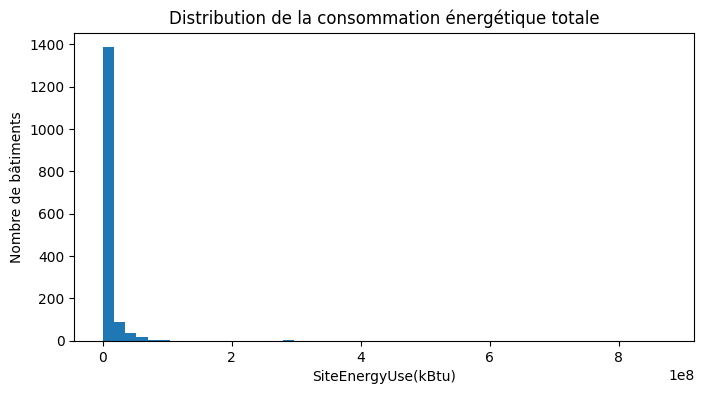

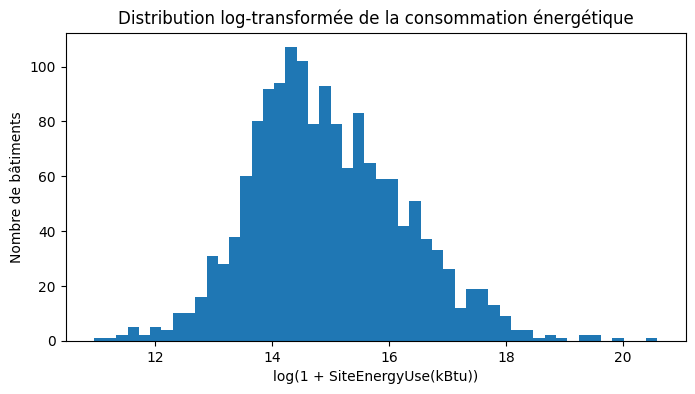

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean[target], bins=50)
plt.title("Distribution de la consommation énergétique totale")
plt.xlabel("SiteEnergyUse(kBtu)")
plt.ylabel("Nombre de bâtiments")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df_clean[target]), bins=50)
plt.title("Distribution log-transformée de la consommation énergétique")
plt.xlabel("log(1 + SiteEnergyUse(kBtu))")
plt.ylabel("Nombre de bâtiments")
plt.show()

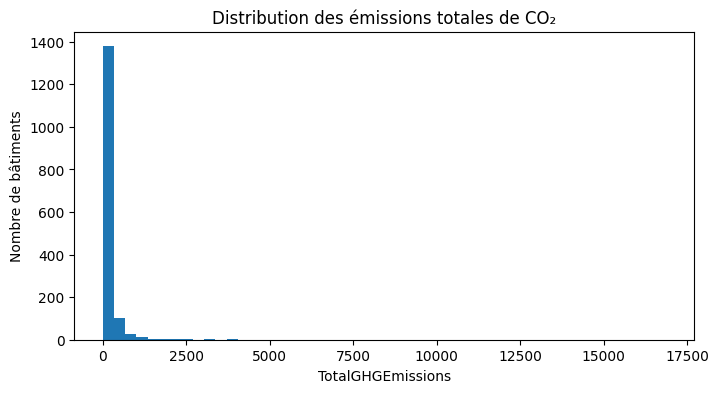

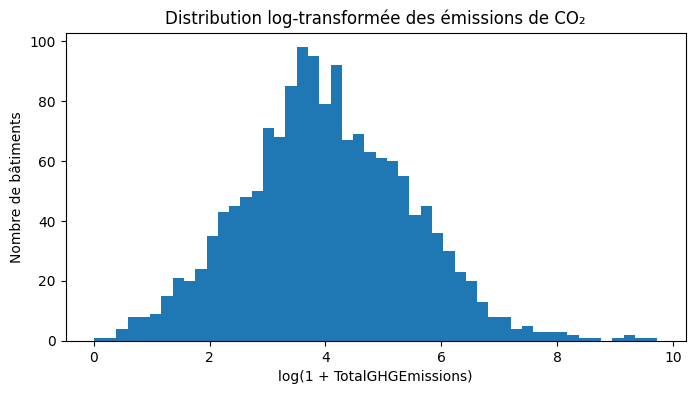

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean[secondary_target], bins=50)
plt.title("Distribution des émissions totales de CO₂")
plt.xlabel("TotalGHGEmissions")
plt.ylabel("Nombre de bâtiments")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df_clean[secondary_target]), bins=50)
plt.title("Distribution log-transformée des émissions de CO₂")
plt.xlabel("log(1 + TotalGHGEmissions)")
plt.ylabel("Nombre de bâtiments")
plt.show()

## 6. Analyse des relations entre variables

On compare les variables quantitatives entre elles avec des scatterplots et une matrice de corrélation. Cela permet de repérer les variables fortement liées à la target, mais aussi les variables redondantes ou susceptibles de créer du data leakage.

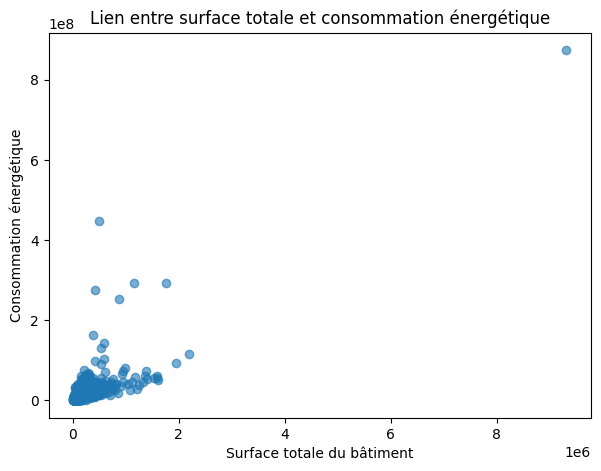

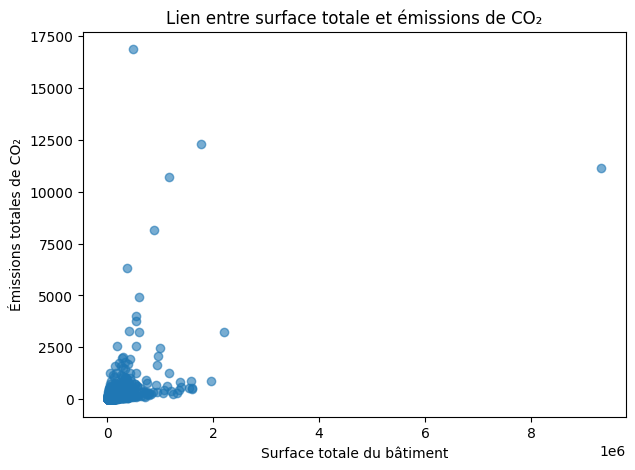

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(df_clean["PropertyGFATotal"], df_clean[target], alpha=0.6)
plt.title("Lien entre surface totale et consommation énergétique")
plt.xlabel("Surface totale du bâtiment")
plt.ylabel("Consommation énergétique")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(df_clean["PropertyGFATotal"], df_clean[secondary_target], alpha=0.6)
plt.title("Lien entre surface totale et émissions de CO₂")
plt.xlabel("Surface totale du bâtiment")
plt.ylabel("Émissions totales de CO₂")
plt.show()

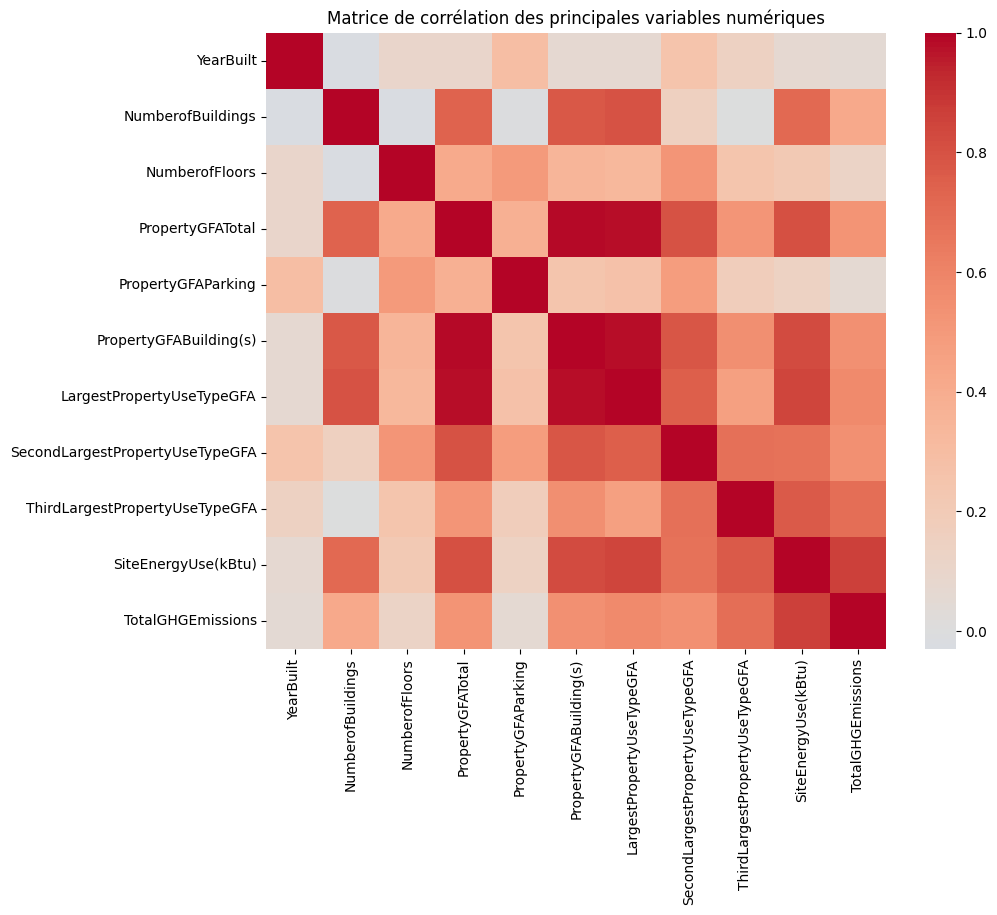

SiteEnergyUse(kBtu)                1.000000
TotalGHGEmissions                  0.860017
LargestPropertyUseTypeGFA          0.846840
PropertyGFABuilding(s)             0.826223
PropertyGFATotal                   0.809620
ThirdLargestPropertyUseTypeGFA     0.765903
NumberofBuildings                  0.714172
SecondLargestPropertyUseTypeGFA    0.670677
NumberofFloors                     0.216410
PropertyGFAParking                 0.141939
YearBuilt                          0.065765
Name: SiteEnergyUse(kBtu), dtype: float64

In [15]:
numeric_cols_for_corr = [
    "YearBuilt", "NumberofBuildings", "NumberofFloors", "PropertyGFATotal",
    "PropertyGFAParking", "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA", target, secondary_target
]

corr_df = df_clean[numeric_cols_for_corr].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation des principales variables numériques")
plt.show()

corr_df[target].sort_values(ascending=False)

## 7. Analyse des variables catégorielles

On analyse les catégories métier comme le type principal de propriété ou le quartier. Pour éviter des graphiques illisibles, on affiche les catégories les plus fréquentes.

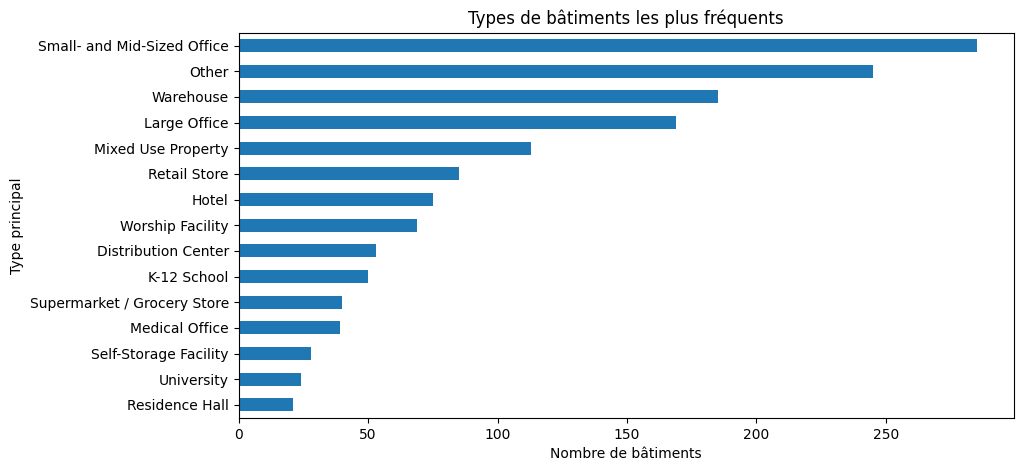

In [16]:
plt.figure(figsize=(10, 5))
counts = df_clean["PrimaryPropertyType"].value_counts().head(15).sort_values()
counts.plot(kind="barh")
plt.title("Types de bâtiments les plus fréquents")
plt.xlabel("Nombre de bâtiments")
plt.ylabel("Type principal")
plt.show()

<Figure size 1000x600 with 0 Axes>

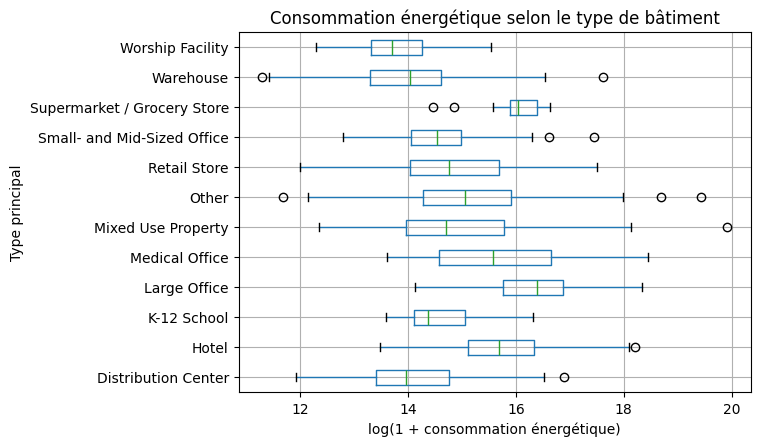

In [17]:
top_property_types = df_clean["PrimaryPropertyType"].value_counts().head(12).index
plot_df = df_clean[df_clean["PrimaryPropertyType"].isin(top_property_types)].copy()
plot_df["log_target"] = np.log1p(plot_df[target])

plt.figure(figsize=(10, 6))
plot_df.boxplot(column="log_target", by="PrimaryPropertyType", vert=False)
plt.title("Consommation énergétique selon le type de bâtiment")
plt.suptitle("")
plt.xlabel("log(1 + consommation énergétique)")
plt.ylabel("Type principal")
plt.show()

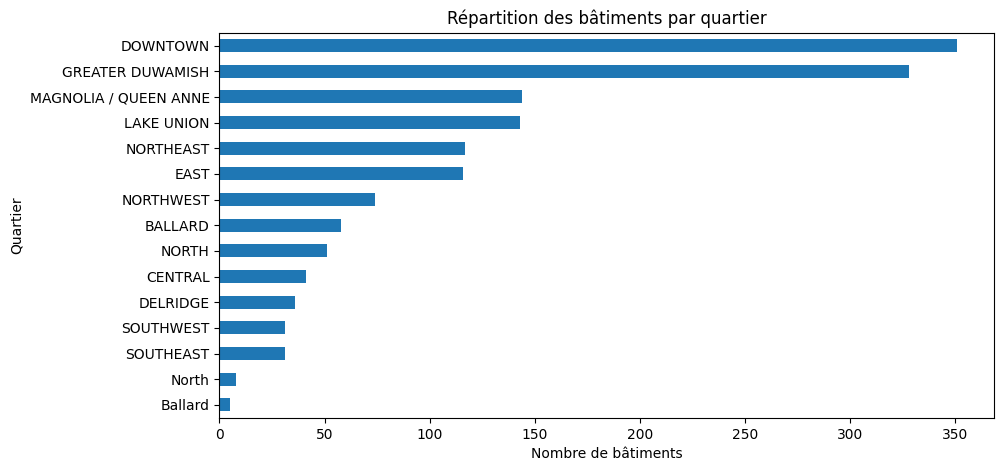

In [18]:
plt.figure(figsize=(10, 5))
counts = df_clean["Neighborhood"].value_counts().head(15).sort_values()
counts.plot(kind="barh")
plt.title("Répartition des bâtiments par quartier")
plt.xlabel("Nombre de bâtiments")
plt.ylabel("Quartier")
plt.show()

## 8. Traitement raisonné des outliers

On ne supprime pas brutalement tous les outliers. On retire seulement les observations très extrêmes de la target, en utilisant les quantiles 1 % et 99 %. Cela limite l’influence de bâtiments atypiques tout en conservant la grande majorité des données.

In [19]:
n_before_outliers = df_clean.shape[0]

low_q = df_clean[target].quantile(0.01)
high_q = df_clean[target].quantile(0.99)

df_clean = df_clean[(df_clean[target] >= low_q) & (df_clean[target] <= high_q)].copy()

print("Seuil bas 1% :", low_q)
print("Seuil haut 99% :", high_q)
print("Lignes avant traitement outliers :", n_before_outliers)
print("Lignes après traitement outliers :", df_clean.shape[0])
print("Lignes supprimées :", n_before_outliers - df_clean.shape[0])

Seuil bas 1% : 182841.933752
Seuil haut 99% : 74639964.47999996
Lignes avant traitement outliers : 1547
Lignes après traitement outliers : 1515
Lignes supprimées : 32


## 9. Synthèse de l’analyse exploratoire

Constats principaux :
- Le dataset initial contient des bâtiments résidentiels et non résidentiels ; seuls les bâtiments non résidentiels sont conservés.
- `SiteEnergyUse(kBtu)` est choisi comme target principale pour prédire la consommation énergétique.
- Les variables liées directement aux consommations d’énergie ou aux émissions ne doivent pas être utilisées comme features, car elles créeraient une fuite de données.
- La surface totale du bâtiment est une variable fortement liée à la consommation.
- Les distributions de consommation et d’émissions sont asymétriques, ce qui justifie une attention particulière aux outliers.
- Le type d’usage du bâtiment et le quartier apportent une information métier intéressante.

# Feature Engineering

## 10. Création de nouvelles features

Le feature engineering consiste à créer des variables plus informatives à partir des colonnes existantes. Les nouvelles features couvrent plusieurs dimensions : temporalité, structure du bâtiment, usages, localisation et qualité des surfaces.

In [20]:
# On repart de la base nettoyée
features_df = df_clean.copy()

# 1) Temporalité : âge du bâtiment en 2016
features_df["BuildingAge"] = features_df["DataYear"] - features_df["YearBuilt"]
features_df["BuildingDecade"] = (features_df["YearBuilt"] // 10 * 10).astype(int).astype(str) + "s"

# 2) Structure : ratios de surface
features_df["ParkingRatio"] = features_df["PropertyGFAParking"] / features_df["PropertyGFATotal"]
features_df["BuildingAreaRatio"] = features_df["PropertyGFABuilding(s)"] / features_df["PropertyGFATotal"]

# 3) Structure : surface moyenne par étage
features_df["AreaPerFloor"] = np.where(
    features_df["NumberofFloors"] > 0,
    features_df["PropertyGFATotal"] / features_df["NumberofFloors"],
    np.nan
)

# 4) Usages : nombre d'usages déclarés
use_cols = ["LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType"]
features_df["NumberOfUseTypes"] = features_df[use_cols].notna().sum(axis=1)
features_df["HasSecondUse"] = features_df["SecondLargestPropertyUseType"].notna().astype(int)
features_df["HasThirdUse"] = features_df["ThirdLargestPropertyUseType"].notna().astype(int)

# 5) Usages : poids relatif des usages principaux dans la surface totale
features_df["LargestUseRatio"] = features_df["LargestPropertyUseTypeGFA"] / features_df["PropertyGFATotal"]
features_df["SecondUseRatio"] = features_df["SecondLargestPropertyUseTypeGFA"].fillna(0) / features_df["PropertyGFATotal"]
features_df["ThirdUseRatio"] = features_df["ThirdLargestPropertyUseTypeGFA"].fillna(0) / features_df["PropertyGFATotal"]

# 6) Catégories regroupées pour limiter la cardinalité
for col, new_col, top_n in [
    ("PrimaryPropertyType", "PrimaryPropertyTypeGrouped", 12),
    ("LargestPropertyUseType", "LargestUseTypeGrouped", 12),
    ("Neighborhood", "NeighborhoodGrouped", 10),
]:
    top_values = features_df[col].value_counts().head(top_n).index
    features_df[new_col] = features_df[col].where(features_df[col].isin(top_values), "Other")

# 7) Tranches de surface et d'âge pour capturer des effets non linéaires simples
features_df["BuildingAgeGroup"] = pd.cut(
    features_df["BuildingAge"],
    bins=[0, 20, 50, 80, 120, np.inf],
    labels=["0-20", "21-50", "51-80", "81-120", "120+"]
)

features_df["TotalGFABin"] = pd.qcut(
    features_df["PropertyGFATotal"],
    q=5,
    duplicates="drop"
)

features_df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,BuildingAge,BuildingDecade,ParkingRatio,BuildingAreaRatio,AreaPerFloor,NumberOfUseTypes,HasSecondUse,HasThirdUse,LargestUseRatio,SecondUseRatio,ThirdUseRatio,PrimaryPropertyTypeGrouped,LargestUseTypeGrouped,NeighborhoodGrouped,BuildingAgeGroup,TotalGFABin
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83,89,1920s,0.000000,1.000000,7369.500000,1,0,0,1.000000,0.000000,0.000000,Hotel,Hotel,DOWNTOWN,81-120,"(61847.0, 132426.4]"
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86,20,1990s,0.145453,0.854547,9415.090909,3,1,1,0.809918,0.145453,0.044629,Hotel,Hotel,DOWNTOWN,0-20,"(61847.0, 132426.4]"
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19,47,1960s,0.205748,0.794252,23319.756098,1,0,0,0.791220,0.000000,0.000000,Hotel,Hotel,DOWNTOWN,21-50,"(132426.4, 1605578.0]"
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67,90,1920s,0.000000,1.000000,6132.000000,1,0,0,1.000000,0.000000,0.000000,Hotel,Hotel,DOWNTOWN,81-120,"(38983.6, 61847.0]"
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88,36,1980s,0.353115,0.646885,9754.444444,3,1,1,0.703070,0.387339,0.000000,Hotel,Hotel,DOWNTOWN,21-50,"(132426.4, 1605578.0]"


## 11. Contrôle des features créées

On vérifie que les nouvelles variables sont cohérentes et qu’elles n’ont pas généré trop de valeurs manquantes ou infinies.

In [21]:
new_features = [
    "BuildingAge", "BuildingDecade", "ParkingRatio", "BuildingAreaRatio", "AreaPerFloor",
    "NumberOfUseTypes", "HasSecondUse", "HasThirdUse",
    "LargestUseRatio", "SecondUseRatio", "ThirdUseRatio",
    "PrimaryPropertyTypeGrouped", "LargestUseTypeGrouped", "NeighborhoodGrouped",
    "BuildingAgeGroup", "TotalGFABin"
]

features_df[new_features].head()

,BuildingAge,BuildingDecade,ParkingRatio,BuildingAreaRatio,AreaPerFloor,NumberOfUseTypes,HasSecondUse,HasThirdUse,LargestUseRatio,SecondUseRatio,ThirdUseRatio,PrimaryPropertyTypeGrouped,LargestUseTypeGrouped,NeighborhoodGrouped,BuildingAgeGroup,TotalGFABin
0,89,1920s,0.000000,1.000000,7369.500000,1,0,0,1.000000,0.000000,0.000000,Hotel,Hotel,DOWNTOWN,81-120,"(61847.0, 132426.4]"
1,20,1990s,0.145453,0.854547,9415.090909,3,1,1,0.809918,0.145453,0.044629,Hotel,Hotel,DOWNTOWN,0-20,"(61847.0, 132426.4]"
2,47,1960s,0.205748,0.794252,23319.756098,1,0,0,0.791220,0.000000,0.000000,Hotel,Hotel,DOWNTOWN,21-50,"(132426.4, 1605578.0]"
3,90,1920s,0.000000,1.000000,6132.000000,1,0,0,1.000000,0.000000,0.000000,Hotel,Hotel,DOWNTOWN,81-120,"(38983.6, 61847.0]"
4,36,1980s,0.353115,0.646885,9754.444444,3,1,1,0.703070,0.387339,0.000000,Hotel,Hotel,DOWNTOWN,21-50,"(132426.4, 1605578.0]"


In [22]:
# Remplacement des valeurs infinies éventuelles
features_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Taux de valeurs manquantes sur les nouvelles features
feature_missing = features_df[new_features].isna().mean().sort_values(ascending=False).round(3)
feature_missing

AreaPerFloor                  0.010
LargestUseRatio               0.003
ParkingRatio                  0.000
BuildingAge                   0.000
BuildingAreaRatio             0.000
NumberOfUseTypes              0.000
HasSecondUse                  0.000
BuildingDecade                0.000
HasThirdUse                   0.000
SecondUseRatio                0.000
ThirdUseRatio                 0.000
PrimaryPropertyTypeGrouped    0.000
LargestUseTypeGrouped         0.000
NeighborhoodGrouped           0.000
BuildingAgeGroup              0.000
TotalGFABin                   0.000
dtype: float64

## 12. Préparation d’un premier jeu de features utilisable ensuite

On prépare une liste de colonnes candidates pour la suite. Les colonnes directement liées à l’énergie, aux émissions ou à des mesures dérivées de la target sont exclues afin d’éviter le data leakage.

In [23]:
# Colonnes interdites pour éviter le data leakage
# Elles décrivent directement la consommation, les émissions ou des intensités dérivées.
leakage_columns = [
    "ENERGYSTARScore",
    "SiteEUI(kBtu/sf)", "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)", "SourceEUIWN(kBtu/sf)",
    "SiteEnergyUse(kBtu)", "SiteEnergyUseWN(kBtu)",
    "SteamUse(kBtu)", "Electricity(kWh)", "Electricity(kBtu)",
    "NaturalGas(therms)", "NaturalGas(kBtu)",
    "TotalGHGEmissions", "GHGEmissionsIntensity"
]

# Variables structurelles et métier conservées pour la suite
numeric_features = [
    "PropertyGFATotal", "PropertyGFAParking", "PropertyGFABuilding(s)",
    "NumberofBuildings", "NumberofFloors", "Latitude", "Longitude",
    "BuildingAge", "ParkingRatio", "BuildingAreaRatio", "AreaPerFloor",
    "NumberOfUseTypes", "HasSecondUse", "HasThirdUse",
    "LargestUseRatio", "SecondUseRatio", "ThirdUseRatio"
]

categorical_features = [
    "BuildingType", "PrimaryPropertyTypeGrouped", "LargestUseTypeGrouped",
    "NeighborhoodGrouped", "BuildingDecade", "BuildingAgeGroup", "TotalGFABin"
]

model_columns = numeric_features + categorical_features + [target]
model_dataset = features_df[model_columns].copy()

print("Dimensions du dataset préparé :", model_dataset.shape)
model_dataset.head()

Dimensions du dataset préparé : (1515, 25)


,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),NumberofBuildings,NumberofFloors,Latitude,Longitude,BuildingAge,ParkingRatio,BuildingAreaRatio,AreaPerFloor,NumberOfUseTypes,HasSecondUse,HasThirdUse,LargestUseRatio,SecondUseRatio,ThirdUseRatio,BuildingType,PrimaryPropertyTypeGrouped,LargestUseTypeGrouped,NeighborhoodGrouped,BuildingDecade,BuildingAgeGroup,TotalGFABin,SiteEnergyUse(kBtu)
0,88434,0,88434,1.0,12,47.61220,-122.33799,89,0.000000,1.000000,7369.500000,1,0,0,1.000000,0.000000,0.000000,NonResidential,Hotel,Hotel,DOWNTOWN,1920s,81-120,"(61847.0, 132426.4]",7226362.5
1,103566,15064,88502,1.0,11,47.61317,-122.33393,20,0.145453,0.854547,9415.090909,3,1,1,0.809918,0.145453,0.044629,NonResidential,Hotel,Hotel,DOWNTOWN,1990s,0-20,"(61847.0, 132426.4]",8387933.0
2,956110,196718,759392,1.0,41,47.61393,-122.33810,47,0.205748,0.794252,23319.756098,1,0,0,0.791220,0.000000,0.000000,NonResidential,Hotel,Hotel,DOWNTOWN,1960s,21-50,"(132426.4, 1605578.0]",72587024.0
3,61320,0,61320,1.0,10,47.61412,-122.33664,90,0.000000,1.000000,6132.000000,1,0,0,1.000000,0.000000,0.000000,NonResidential,Hotel,Hotel,DOWNTOWN,1920s,81-120,"(38983.6, 61847.0]",6794584.0
4,175580,62000,113580,1.0,18,47.61375,-122.34047,36,0.353115,0.646885,9754.444444,3,1,1,0.703070,0.387339,0.000000,NonResidential,Hotel,Hotel,DOWNTOWN,1980s,21-50,"(132426.4, 1605578.0]",14172606.0


In [24]:
# Dernière vérification : aucune colonne de leakage dans les features candidates
selected_feature_cols = numeric_features + categorical_features
leakage_in_features = sorted(set(selected_feature_cols).intersection(leakage_columns))
print("Colonnes de leakage présentes dans les features :", leakage_in_features)

# Aperçu des types de colonnes pour la suite du notebook
model_dataset.dtypes

Colonnes de leakage présentes dans les features : []


PropertyGFATotal                 int64
PropertyGFAParking               int64
PropertyGFABuilding(s)           int64
NumberofBuildings              float64
NumberofFloors                   int64
Latitude                       float64
Longitude                      float64
BuildingAge                      int64
ParkingRatio                   float64
BuildingAreaRatio              float64
AreaPerFloor                   float64
NumberOfUseTypes                 int64
HasSecondUse                     int64
HasThirdUse                      int64
LargestUseRatio                float64
SecondUseRatio                 float64
ThirdUseRatio                  float64
BuildingType                       str
PrimaryPropertyTypeGrouped         str
LargestUseTypeGrouped              str
NeighborhoodGrouped                str
BuildingDecade                     str
BuildingAgeGroup              category
TotalGFABin                   category
SiteEnergyUse(kBtu)            float64
dtype: object

## 13. Synthèse du feature engineering

Nouvelles variables créées :
- `BuildingAge` et `BuildingDecade` pour représenter l’ancienneté du bâtiment.
- `ParkingRatio`, `BuildingAreaRatio` et `AreaPerFloor` pour mieux décrire la structure du bâtiment.
- `NumberOfUseTypes`, `HasSecondUse`, `HasThirdUse` et les ratios d’usage pour distinguer les bâtiments mono-usage et multi-usages.
- Des regroupements de catégories (`PrimaryPropertyTypeGrouped`, `LargestUseTypeGrouped`, `NeighborhoodGrouped`) pour éviter une cardinalité trop élevée.
- Des tranches d’âge et de surface pour capturer des effets non linéaires simples.

Choix méthodologique important : les colonnes de consommation d’énergie, d’émissions et d’intensité énergétique ne sont pas utilisées comme features, car elles donneraient au modèle des informations trop proches de la target à prédire.

# Modélisation 

### Import des modules 

In [25]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [26]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [27]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [28]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [29]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE